# Normalizing Flow Model Validation

Interactive notebook for visualizing and validating normalizing flow models trained on FAIR Universe data.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from typing import List
import numpy as np
import torch
import os
import sys

from fair_universe_demo.models.classifier_datamodule import ClassifierDatamodule
from fair_universe_demo.tasks.histogram import HistogramTask
from fair_universe_demo.utils.selection import createJetData
from fair_universe_demo.tasks.plot import PlottingMixin

2026-04-21 09:16:44,620 - luigi-interface      - INFO     - Loaded []


## Configuration

In [3]:
# Global Configuration Variables
snapshot_path = "../../runs/fair_universe_demo_debugging/dag_snapshot.json"
use_test_data = False
root_dir = {True: "./test_data/", False: os.getenv("FAIR_UNIVERSE_DATA")}[use_test_data]
plot_save_dir = "../../runs/fair_universe_demo_debugging/plots/"

# Global data storage (will be populated in setup)
signal_data = None
bg_data = None
signal_logprobs = None
bg_logprobs = None
nf_model = None
model_name = None
device = "cuda" if torch.cuda.is_available() else "cpu"

## Setup and Data Loading

In [4]:
def setup():
    """Load NF models from snapshot and prepare data for the first model."""
    global signal_data, bg_data, signal_logprobs, bg_logprobs, nf_model, model_name, device
    
    # Parse snapshot to get NF models
    nf_ckpts, _ = HistogramTask.parse_snapshot(snapshot_path)
    nf_models = ClassifierDatamodule.load_nf_models(nf_ckpts)
    
    # Get the first model only
    model_name, nf_model = list(nf_models.items())[1]
    print(f"Loading model: {model_name}")
    
    nf_model = nf_model.to(device).eval()
    
    os.makedirs(plot_save_dir, exist_ok=True)
    
    # Extract jet count from model name (e.g., "nf_signal_1jet&c_0p5" -> 1 or 2)
    name_parts = model_name.split('&')[0]  # "nf_signal_1jet" or "nf_background_2jet"
    if '1jet' in name_parts:
        num_jets = 1
    elif '2jet' in name_parts:
        num_jets = 2
    else:
        raise ValueError(f"Could not extract jet count from model name: {model_name}")
    
    # Load validation data
    print(f"Loading validation data for {num_jets} jets...")
    data, detlabel, _, _ = createJetData(
        jet_num=num_jets,
        useTestData=False,
        seed=78,
        root_dir=root_dir,
    )
    
    # Split by signal (1) and background (0)
    signal_mask = detlabel == 1
    bg_mask = detlabel == 0
    
    signal_data = data[signal_mask]
    bg_data = data[bg_mask]
    
    # Evaluate model on both signal and background
    print("Evaluating model on signal and background data...")
    with torch.no_grad():
        signal_logprobs = nf_model(signal_data.to(device)).cpu().numpy()
        bg_logprobs = nf_model(bg_data.to(device)).cpu().numpy()
    
    print(f"Loaded {len(signal_logprobs)} signal and {len(bg_logprobs)} background samples")
    print(f"Signal log-probs: mean={np.mean(signal_logprobs):.3f}, std={np.std(signal_logprobs):.3f}")
    print(f"Background log-probs: mean={np.mean(bg_logprobs):.3f}, std={np.std(bg_logprobs):.3f}")

# Run setup
setup()

Loading model: nf_signal_1jet&c_2p0


2026-04-21 09:16:46,472 - FAIR-Universe-Data   - INFO     - Opening file /work/kschmidt/NEEDLE/merged/FAIR_Universe_HiggsML_data.parquet


Loading validation data for 1 jets...


Loading data from parquet file: 100%|██████████| 210/210 [00:18<00:00, 11.48row_groups/s]


Evaluating model on signal and background data...
Loaded 471659 signal and 603243 background samples
Signal log-probs: mean=-10.911, std=7.709
Background log-probs: mean=-12.776, std=489.205


## Plot 1: Log-Probability Distributions

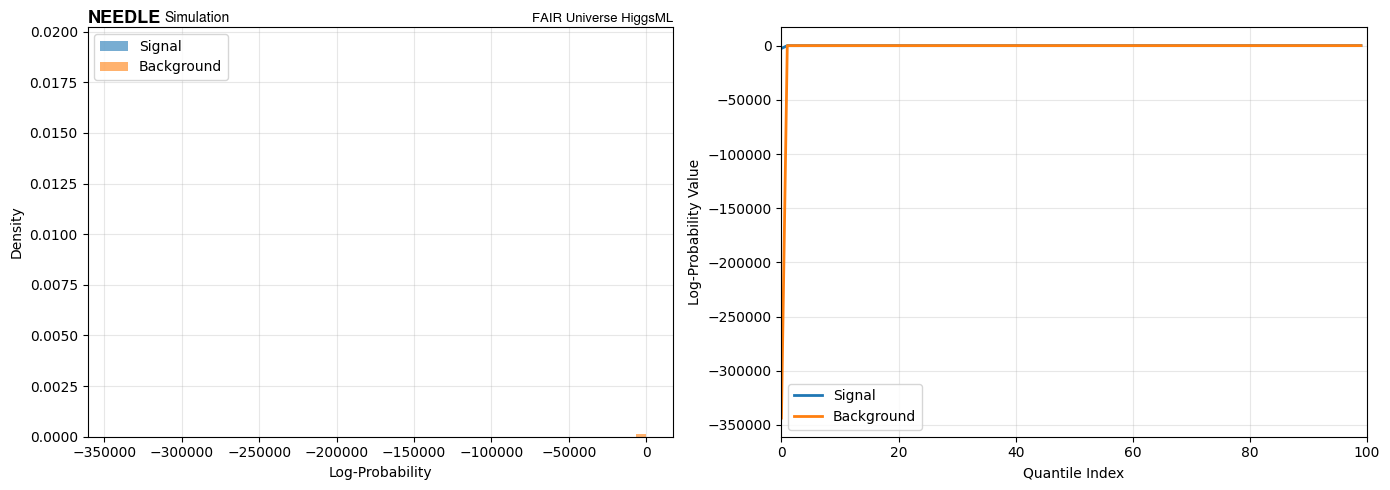

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram comparison
axes[0].hist(signal_logprobs, bins=50, alpha=0.6, label='Signal', density=True)
axes[0].hist(bg_logprobs, bins=50, alpha=0.6, label='Background', density=True)
axes[0].set_xlabel('Log-Probability')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Quantile comparison
q_sig = np.quantile(signal_logprobs, np.linspace(0, 1, 100))
q_bg = np.quantile(bg_logprobs, np.linspace(0, 1, 100))
axes[1].plot(q_sig, label='Signal', linewidth=2)
axes[1].plot(q_bg, label='Background', linewidth=2)
axes[1].set_xlabel('Quantile Index')
axes[1].set_ylabel('Log-Probability Value')
axes[1].legend()
axes[1].set_xlim(0, 100)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

fig = PlottingMixin.set_needle_plot_style(fig)

plt.show()

## Plot 2: Log-Probability Statistics

/tmp/ipykernel_991698/788413266.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=['Signal', 'Background'], patch_artist=True)


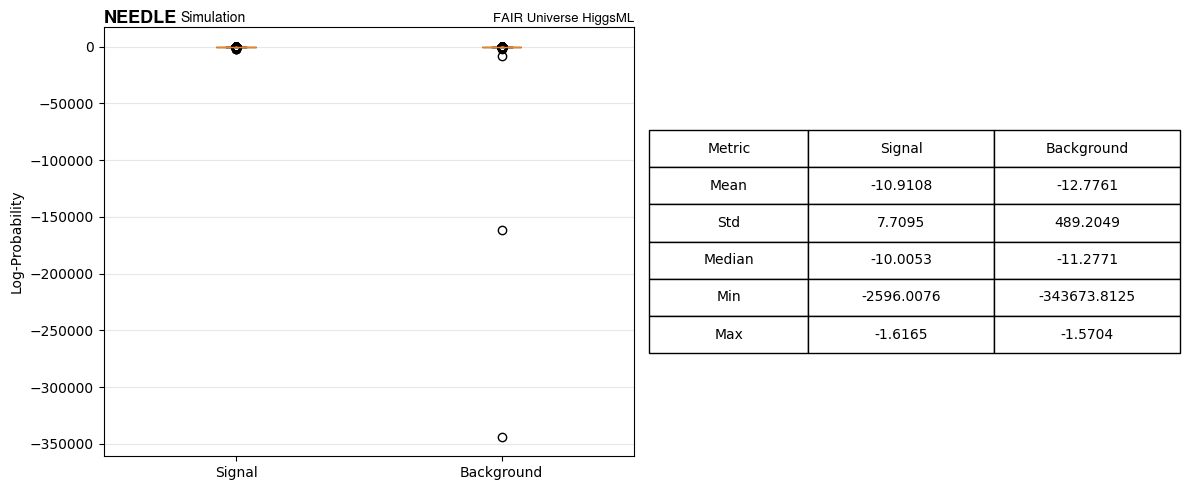

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
data_to_plot = [signal_logprobs, bg_logprobs]
bp = axes[0].boxplot(data_to_plot, labels=['Signal', 'Background'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
axes[0].set_ylabel('Log-Probability')
axes[0].grid(True, alpha=0.3, axis='y')

# Statistics table
stats = {
    'Signal': {
        'Mean': np.mean(signal_logprobs),
        'Std': np.std(signal_logprobs),
        'Median': np.median(signal_logprobs),
        'Min': np.min(signal_logprobs),
        'Max': np.max(signal_logprobs),
    },
    'Background': {
        'Mean': np.mean(bg_logprobs),
        'Std': np.std(bg_logprobs),
        'Median': np.median(bg_logprobs),
        'Min': np.min(bg_logprobs),
        'Max': np.max(bg_logprobs),
    },
}

axes[1].axis('off')
table_data = [['Metric', 'Signal', 'Background']]
for metric in ['Mean', 'Std', 'Median', 'Min', 'Max']:
    table_data.append([
        metric,
        f"{stats['Signal'][metric]:.4f}",
        f"{stats['Background'][metric]:.4f}",
    ])

table = axes[1].table(
    table_data,
    cellLoc='center',
    loc='center',
    colWidths=[0.3, 0.35, 0.35],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

plt.tight_layout()
fig = PlottingMixin.set_needle_plot_style(fig)
plt.show()


## Plot 3: Log-Probability vs Feature

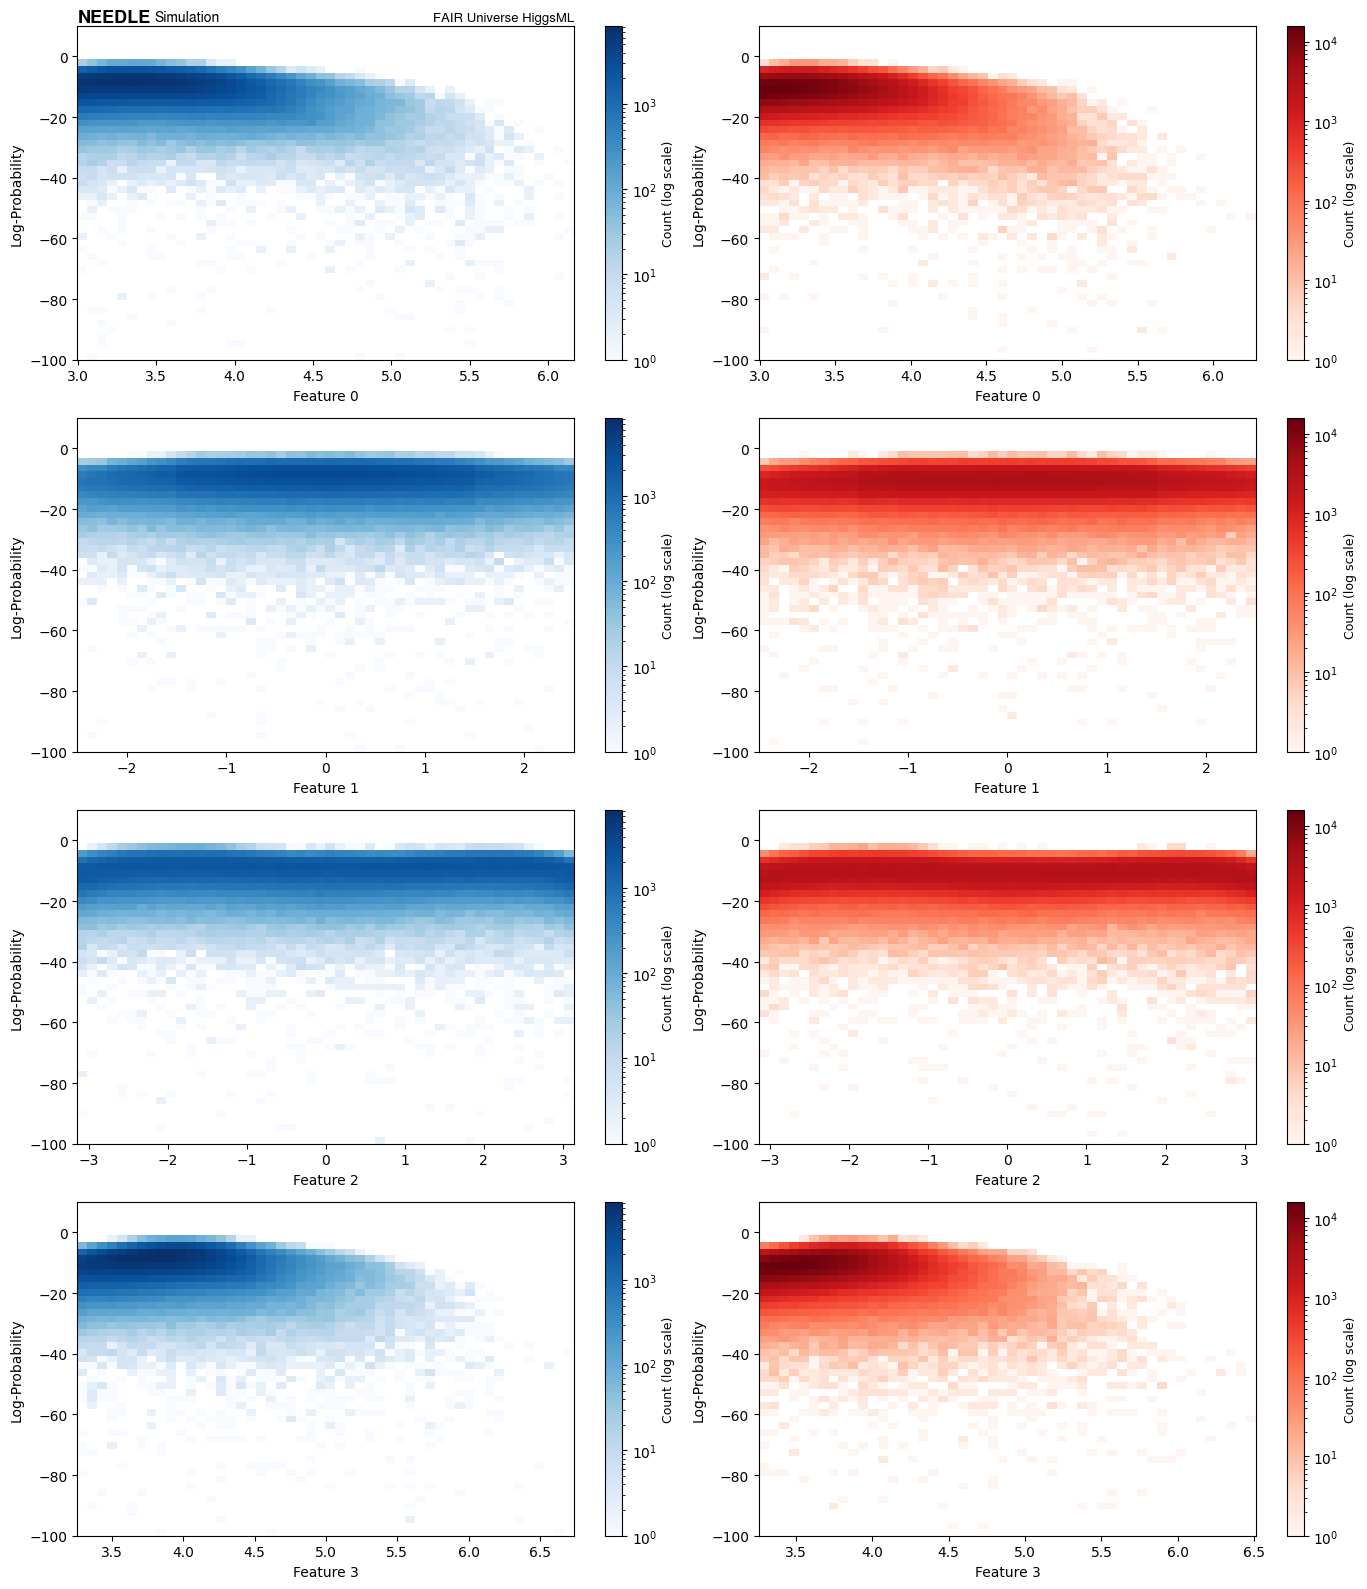

Saved: ../../runs/fair_universe_demo_debugging/plots/nf_signal_1jet&c_2p0_log_prob_vs_feature.png


In [7]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

sig_data_np = signal_data.cpu().numpy()
bg_data_np = bg_data.cpu().numpy()

# Define y-range for binning
y_min, y_max = -100, 10

# Filter data to the specified y-range
sig_mask = (signal_logprobs >= y_min) & (signal_logprobs <= y_max)
bg_mask = (bg_logprobs >= y_min) & (bg_logprobs <= y_max)

sig_data_filtered = sig_data_np[sig_mask]
sig_logprobs_filtered = signal_logprobs[sig_mask]
bg_data_filtered = bg_data_np[bg_mask]
bg_logprobs_filtered = bg_logprobs[bg_mask]

# Get common scale for colorbars
vmin = 1  # Avoid log(0)
vmax_sig = 0
vmax_bg = 0

for i in range(4):
    h_sig, _, _ = np.histogram2d(sig_data_filtered[:, i], sig_logprobs_filtered, bins=50, range=[[sig_data_filtered[:, i].min(), sig_data_filtered[:, i].max()], [y_min, y_max]])
    h_bg, _, _ = np.histogram2d(bg_data_filtered[:, i], bg_logprobs_filtered, bins=50, range=[[bg_data_filtered[:, i].min(), bg_data_filtered[:, i].max()], [y_min, y_max]])
    vmax_sig = max(vmax_sig, h_sig.max())
    vmax_bg = max(vmax_bg, h_bg.max())

for i in range(4):
    # Signal heatmap (left)
    x_min_sig, x_max_sig = sig_data_filtered[:, i].min(), sig_data_filtered[:, i].max()
    h_sig, xedges, yedges = np.histogram2d(sig_data_filtered[:, i], sig_logprobs_filtered, bins=50, range=[[x_min_sig, x_max_sig], [y_min, y_max]])
    im_sig = axes[i, 0].imshow(h_sig.T, origin='lower', aspect='auto', cmap='Blues', 
                               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                               norm=LogNorm(vmin=vmin, vmax=vmax_sig))
    axes[i, 0].set_xlabel(f'Feature {i}', fontsize=10)
    axes[i, 0].set_ylabel('Log-Probability', fontsize=10)
    axes[i, 0].set_ylim(y_min, y_max)
    cbar_sig = plt.colorbar(im_sig, ax=axes[i, 0])
    cbar_sig.set_label('Count (log scale)', fontsize=9)
    
    # Background heatmap (right)
    x_min_bg, x_max_bg = bg_data_filtered[:, i].min(), bg_data_filtered[:, i].max()
    h_bg, xedges, yedges = np.histogram2d(bg_data_filtered[:, i], bg_logprobs_filtered, bins=50, range=[[x_min_bg, x_max_bg], [y_min, y_max]])
    im_bg = axes[i, 1].imshow(h_bg.T, origin='lower', aspect='auto', cmap='Reds',
                              extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                              norm=LogNorm(vmin=vmin, vmax=vmax_bg))
    axes[i, 1].set_xlabel(f'Feature {i}', fontsize=10)
    axes[i, 1].set_ylabel('Log-Probability', fontsize=10)
    axes[i, 1].set_ylim(y_min, y_max)
    cbar_bg = plt.colorbar(im_bg, ax=axes[i, 1])
    cbar_bg.set_label('Count (log scale)', fontsize=9)

plt.tight_layout()
fig = PlottingMixin.set_needle_plot_style(fig)
plt.show()

# Save figure
fig_path = os.path.join(plot_save_dir, f"{model_name}_log_prob_vs_feature.png")
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")

## Plot 5: Calibration Curve (ROC)

In [8]:
signal_logprobs

array([-10.403097, -11.090077,  -8.741787, ..., -12.332894, -16.052658,
        -8.951396], shape=(471659,), dtype=float32)

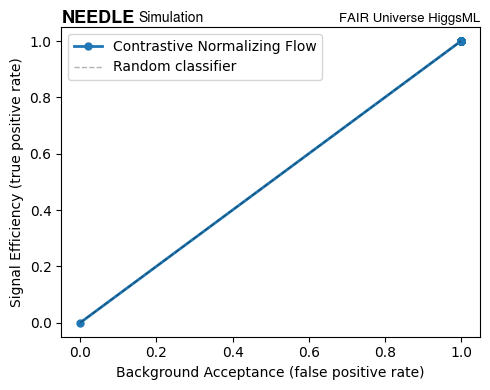

Saved: ../../runs/fair_universe_demo_debugging/plots/nf_signal_1jet&c_2p0_calibration_curve.png


In [9]:
num_bins = 20
thresholds = np.linspace(
    min(signal_logprobs.min(), bg_logprobs.min()),
    max(signal_logprobs.max(), bg_logprobs.max()),
    num_bins,
)

sig_eff = []  # Fraction of signal above threshold (true positive rate)
bg_acc = []   # Fraction of background above threshold (false positive rate)

for thresh in thresholds:
    sig_eff.append(np.mean(signal_logprobs > thresh))
    bg_acc.append(np.mean(bg_logprobs > thresh))

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(
    bg_acc,
    sig_eff,
    linewidth=2,
    marker='o',
    markersize=5,
    label="Contrastive Normalizing Flow",
)
ax.set_xlabel('Background Acceptance (false positive rate)')
ax.set_ylabel('Signal Efficiency (true positive rate)')
# ax.set_xlim(*[0, 1])
# ax.set_ylim(*[0, 1])

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='Random classifier')
ax.legend()

plt.tight_layout()
fig = PlottingMixin.set_needle_plot_style(fig)
plt.show()

# Save figure
fig_path = os.path.join(plot_save_dir, f"{model_name}_calibration_curve.png")
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")

## Plot 6: Feature Distributions

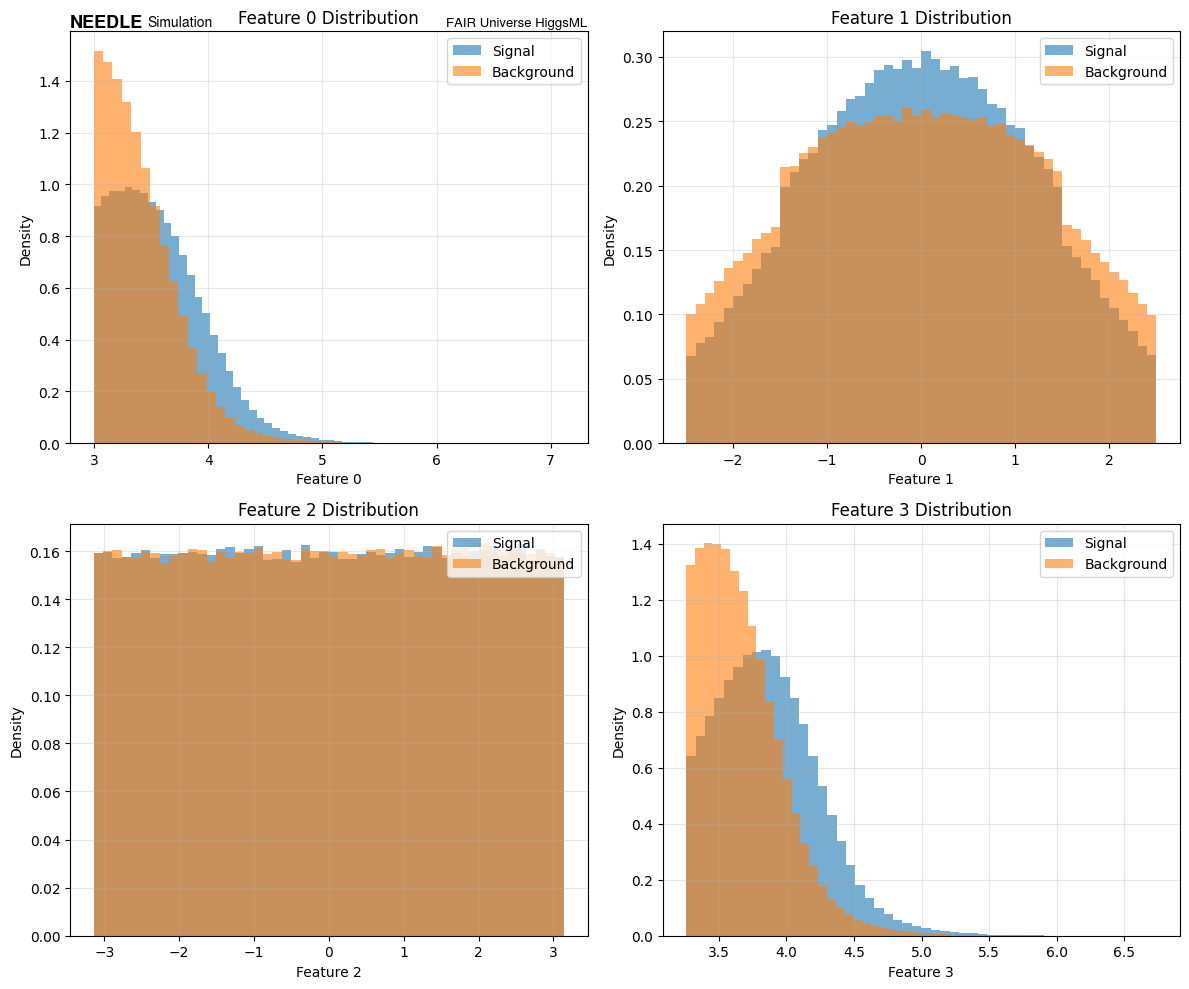

Saved: ../../runs/fair_universe_demo_debugging/plots/nf_signal_1jet&c_2p0_feature_distribution.png

All plots saved to: ../../runs/fair_universe_demo_debugging/plots/


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

sig_data_np = signal_data.cpu().numpy()
bg_data_np = bg_data.cpu().numpy()

for i in range(min(4, 4)):
    axes[i].hist(sig_data_np[:, i], bins=50, alpha=0.6, label='Signal', density=True)
    axes[i].hist(bg_data_np[:, i], bins=50, alpha=0.6, label='Background', density=True)
    axes[i].set_xlabel(f'Feature {i}')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'Feature {i} Distribution')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

fig = PlottingMixin.set_needle_plot_style(fig)
plt.tight_layout()
plt.show()

# Save figure
fig_path = os.path.join(plot_save_dir, f"{model_name}_feature_distribution.png")
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")
print(f"\nAll plots saved to: {plot_save_dir}")